In [1]:
# Import standard packages
import numpy as np
import pandas as pd
import os
import pywt 

# Import plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
directory_name = input('CSV File Directory:')

In [3]:
# Navigate to the csv files directory
os.chdir(directory_name)

In [4]:
# current directory csv files
csvs = [x for x in os.listdir(directory_name) if x.endswith('.csv')]
# stats.csv -> stats
fns = [os.path.splitext(os.path.basename(x))[0] for x in csvs]

dic_csv = {}
for i in range(len(fns)):
    dic_csv[fns[i]] = pd.read_csv(csvs[i])

In [5]:
#for key, df in dic_csv.items():
    #df.rename(columns={'P3-Air-Supply-pressure':'P3-Air Suction Pressure','P3-CPM':'P3_CPM'},inplace=True)

In [5]:
clean_dic={}

In [7]:
#Collect all columname in the list
for df in dic_csv.values():
    parametername_list=list(set(df.columns))
#Identify the correct parameter name from the list
if 'P1-Air-Supply-pressure' in parametername_list:
    parameter_name= 'P1-Air-Supply-pressure'
elif 'P2-Air-Supply-pressure' in parametername_list:
    parameter_name='P2-Air-Supply-pressure'
elif 'P3-Air Suction Pressure' in parametername_list:
    parameter_name='P3-Air Suction Pressure'
else:
    parameter_name=None
#Print the parameter name
print(parameter_name)

P3-Air Suction Pressure


In [8]:
for key, df in dic_csv.items():
    clean_dic[key] = df[df[parameter_name] > 90]

In [9]:
for key, df in clean_dic.items():
    df.reset_index(inplace=True, drop=True)

In [10]:
# Generate the list of date elements based on the number of keys
Month_date_list = pd.date_range('2024-04-11 00:00:00.000', freq='1D', periods=len(clean_dic)).strftime('%Y-%m-%d %H:%M:%S.%f').tolist()
#Create new timeline
for (key, df), i in zip(clean_dic.items(),Month_date_list) :    
    df['newtime'] = pd.date_range(i, freq='30ms', periods=len(df))
    df['newtime'] =pd.to_datetime(df['newtime'])
    df.set_index(['newtime'], inplace=True)


C:\Users\Admin\AppData\Local\Temp\ipykernel_14460\2482457632.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['newtime'] = pd.date_range(i, freq='30ms', periods=len(df))
C:\Users\Admin\AppData\Local\Temp\ipykernel_14460\2482457632.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['newtime'] =pd.to_datetime(df['newtime'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_14460\2482457632.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

In [11]:
clean_dic.keys()

dict_keys(['01_P3_LT-II_14Oct23', '02_P3_LT-II_15Oct23', '03_P3_LT-II_16Oct23', '04_P3_LT-II_17Oct23', '05_P3_LT-II_18Oct23', '06_P3_LT-II_19Oct23', '07_P3_LT-II_20Oct23', '08_P3_LT-II_21Oct23', '09_P3_LT-II_22Oct23', '10_P3_LT-II_23Oct23', '11_P3_LT-II_24Oct23', '12_P3_LT-II_25Oct23', '13_P3_LT-II_26Oct23', '14_P3_LT-II_27Oct23', '15_P3_LT-II_28Oct23', '16_P3_LT-II_29Oct23', '18_P3_LT-II_31Oct23', '19_P3_LT-II_01Nov23', '20_P3_LT-II_02Nov23', '21_P3_LT-II_03Nov23', '22_P3_LT-II_06Nov23'])

In [12]:
len(clean_dic)

21

In [13]:
level=3

In [25]:
mean_dic = {}
stadev_dic = {}
for lsindex in range(level):
    mean_dic['mean_{}'.format(lsindex+1)] = pd.DataFrame()
    stadev_dic['stddev_{}'.format(lsindex+1)] = pd.DataFrame()
for key, df in clean_dic.items():
    # Define the time interval for slicing
    start_time = df.index[0]
    end_time = df.index[-1]
    time_interval = pd.Timedelta(minutes=20)

    stddev = [[] for _ in range(level)]
    mean = [[] for _ in range(level)]
    
    current_time = start_time
    while current_time <= end_time:
        next_time = current_time + time_interval

        # Slice the DataFrame based on the specified time range
        sliced_df = df.loc[(df.index >= current_time) & (df.index <= next_time)]
        
        n = len(sliced_df)
        if n > 0:
            coeffs = pywt.wavedec(sliced_df[parameter_name], 'db4', level=level, mode='symmetric')
            reconstructed_details = []
            for i in range(0, level+1):
                coeffs_copy = [np.zeros_like(c) for c in coeffs]
                coeffs_copy[i] = coeffs[i]
                reconstructed_detail = pywt.waverec(coeffs_copy, 'db4', mode='symmetric')
                reconstructed_details.append(reconstructed_detail)

            for decom_iter in range(1, level+1):
                decomposed_data_set = reconstructed_details[decom_iter]
                mean[decom_iter - 1].append(np.mean(decomposed_data_set))
                stddev[decom_iter - 1].append(np.std(decomposed_data_set))
        else:
            pass
        current_time = next_time
        
    # Store the computed mean and standard deviation values into the corresponding DataFrames
    for mean_key,stddev_key, lsindex in zip(mean_dic.keys(),stadev_dic.keys(),range(level)) :
        mean_dic[mean_key][key] = pd.DataFrame(mean[lsindex],columns=[key])
        stadev_dic[stddev_key][key] = pd.DataFrame(stddev[lsindex],columns=[key])


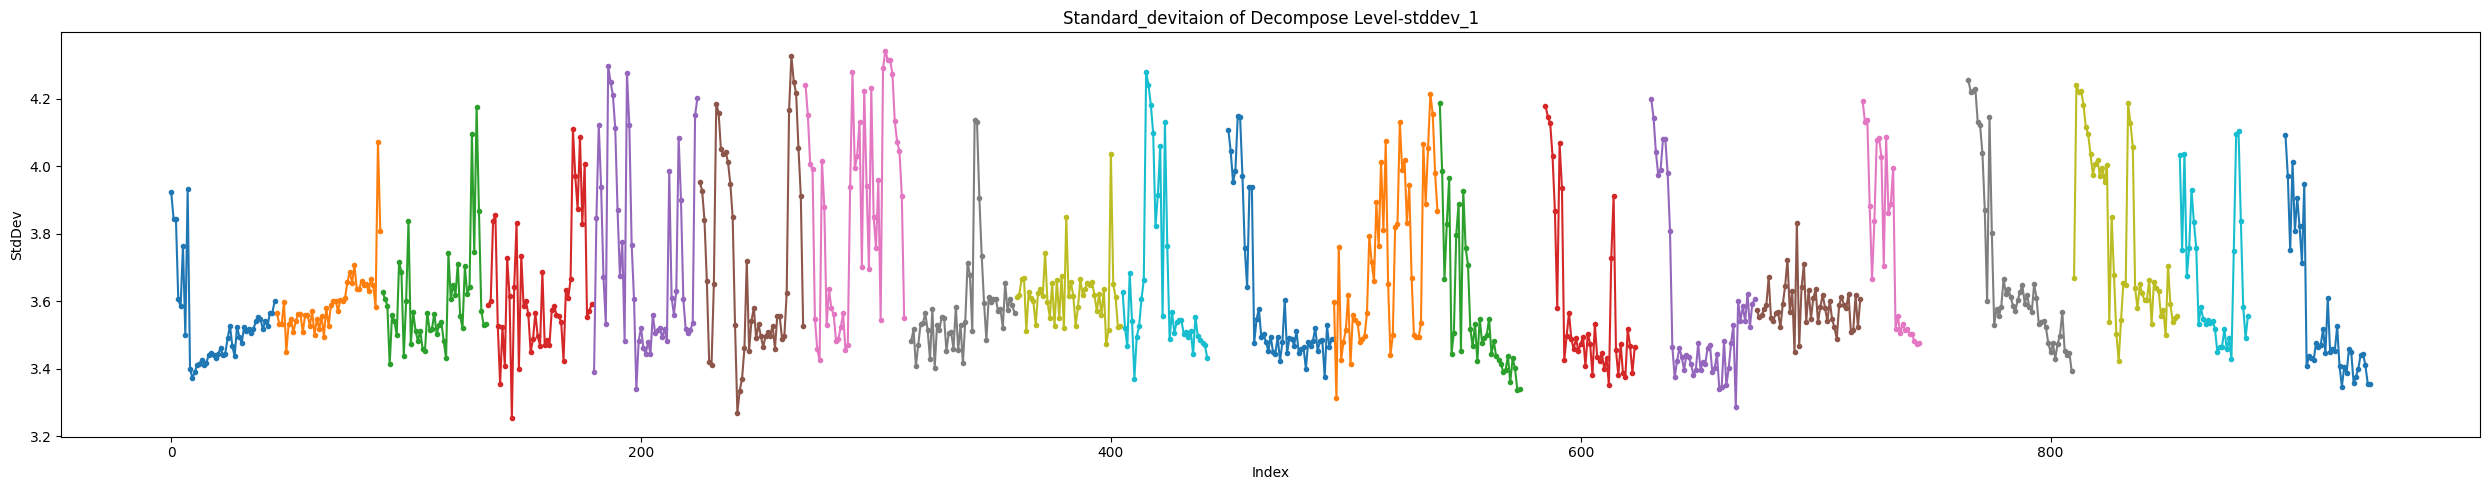

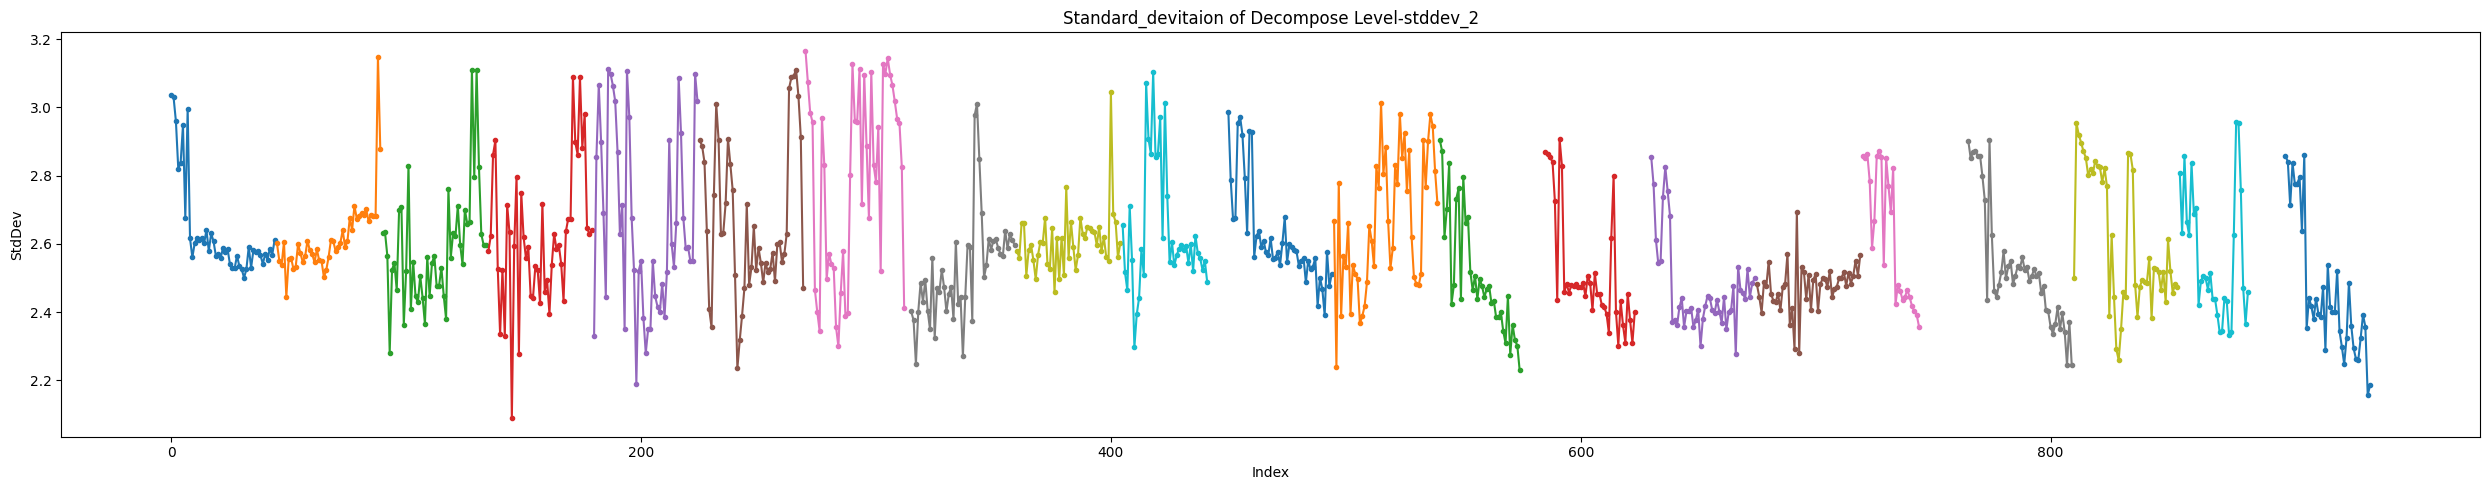

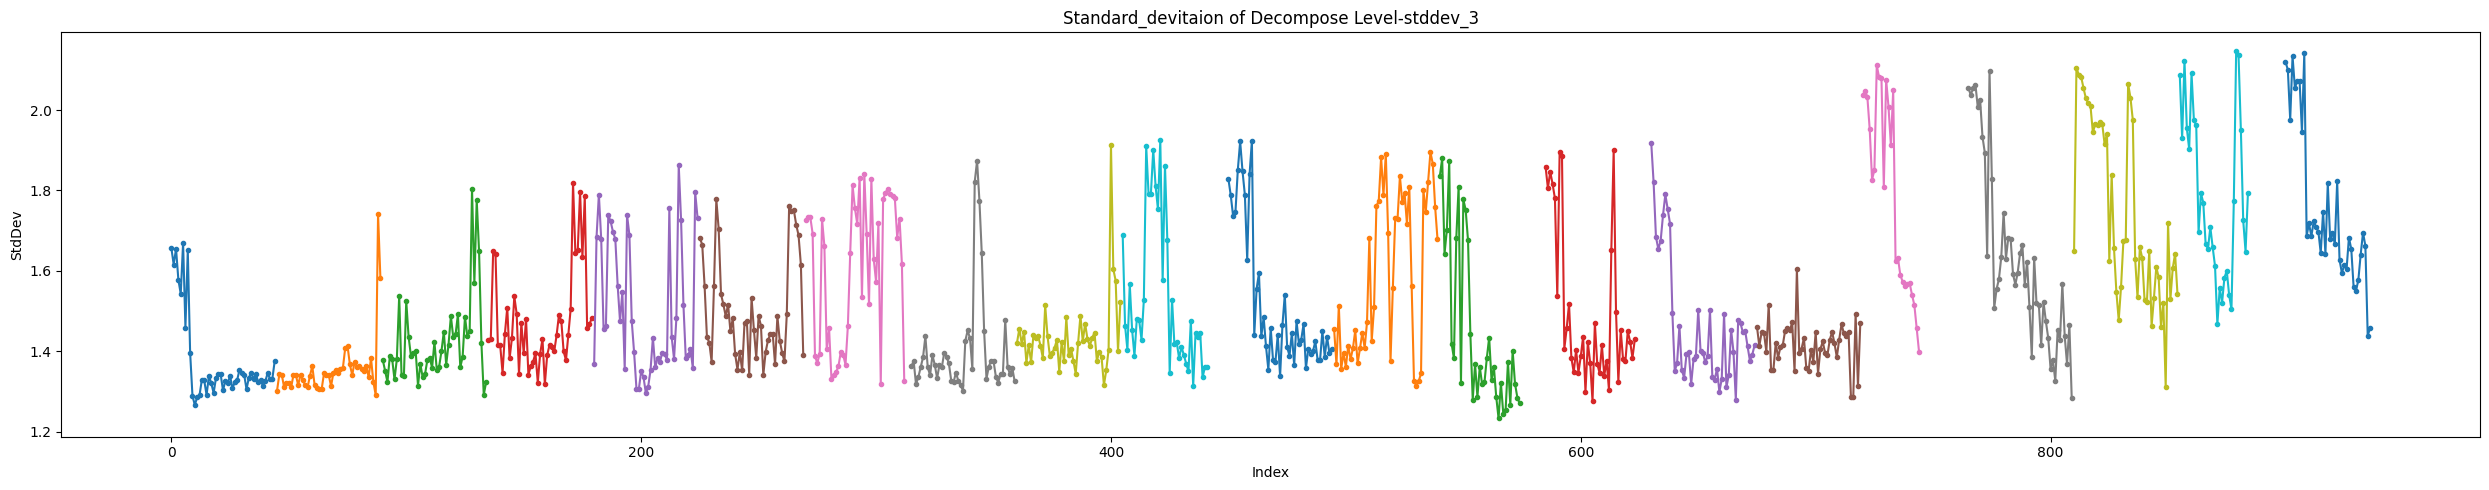

In [30]:
a = len(stadev_dic)  # number of rows
b = 1  # number of columns
c = 1  # initialize plot counter
for key,df in stadev_dic.items():
    plt.figure(figsize=(25, 5))
    x_start = 0
    for idx in list(df.columns):
        x_end = x_start + len(df.index)
        x_values = range(x_start, x_end)
        plt.plot(x_values, df[idx],marker='.')
        x_start = x_end
    plt.xlabel('Index')
    plt.ylabel('StdDev')
    plt.title('Standard_devitaion of Decompose Level-{}'.format(key))
    #plt.legend(loc='best')
    plt.tight_layout()
    plt.show();
    

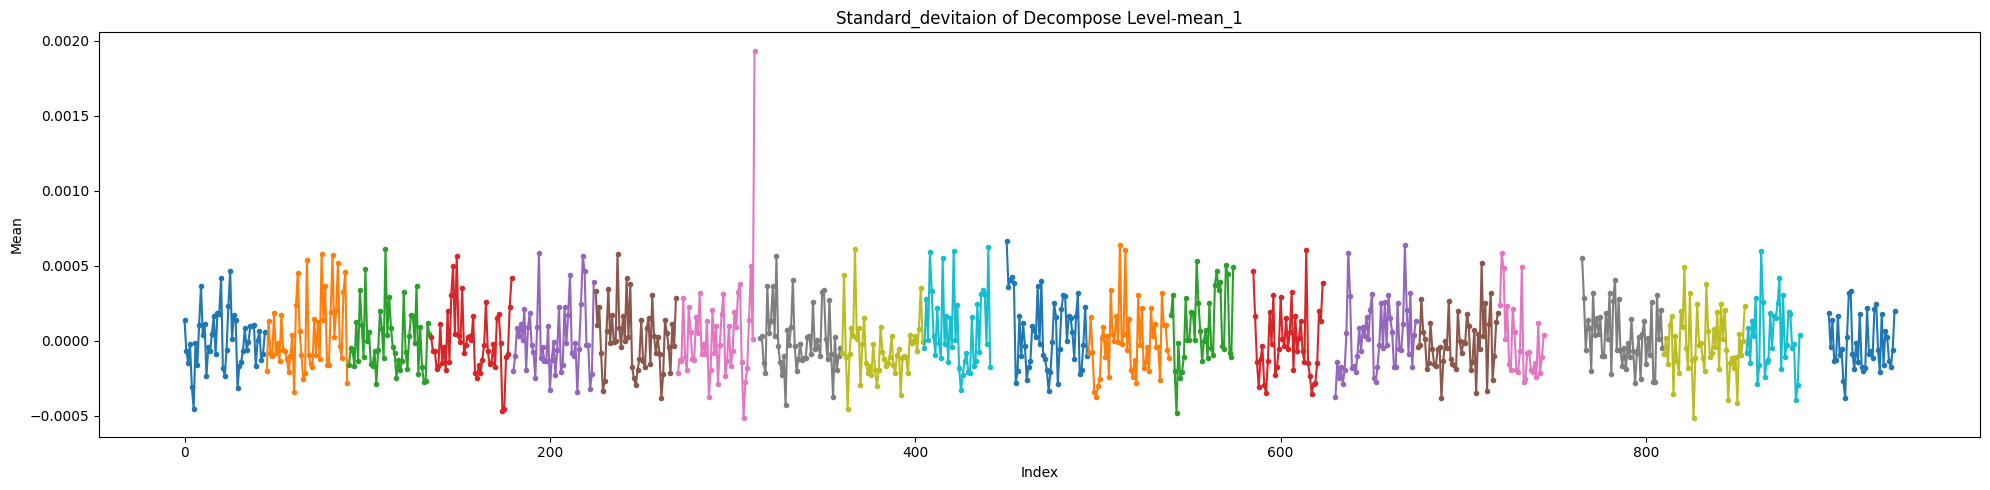

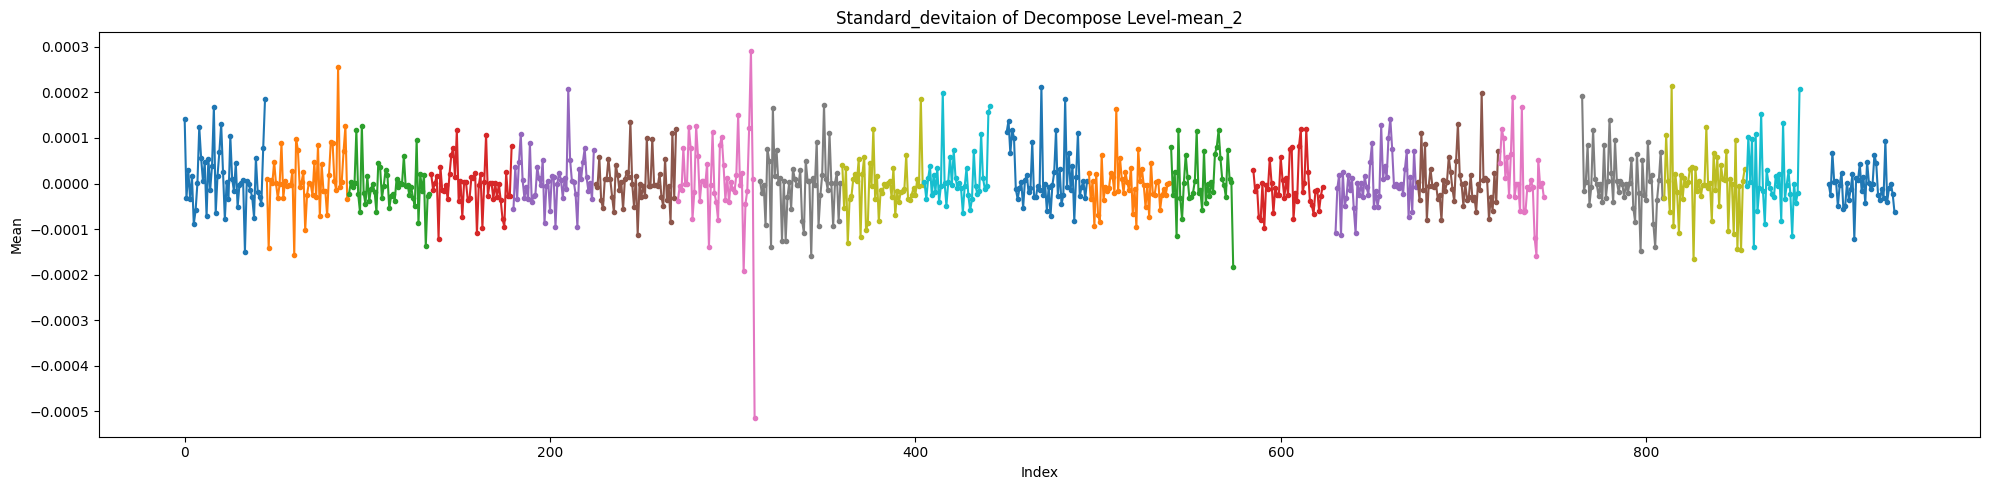

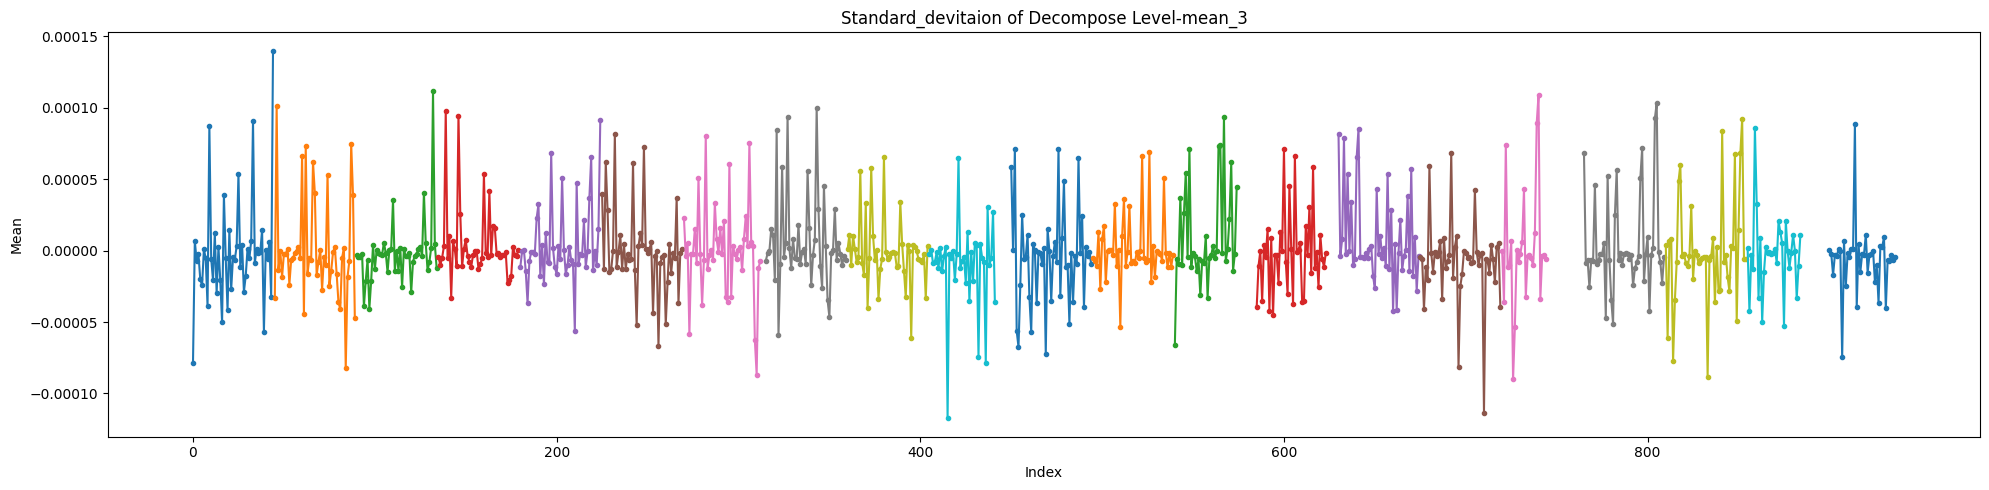

In [20]:
a = len(mean_dic)  # number of rows
b = 1  # number of columns
c = 1  # initialize plot counter
for key,df in mean_dic.items():
    plt.figure(figsize=(20,5))
    x_start = 0
    for idx in list(df.columns):
        x_end = x_start + len(df.index)
        x_values = range(x_start, x_end)
        plt.plot(x_values, df[idx],marker='.')
        x_start = x_end
    plt.xlabel('Index')
    plt.ylabel('Mean')
    plt.title('Standard_devitaion of Decompose Level-{}'.format(key))
    #plt.legend(loc='best')
    plt.tight_layout()
    plt.show();
    

In [14]:
#Calculate Total Run Time 
total_hrs=0
for key,df in clean_dic.items():
   hrs=np.round((((df.index[-1]-df.index[0]).total_seconds())/3600),decimals=1)
   total_hrs=total_hrs+hrs

In [ ]:
#for key, df in result_df.items():
    #df.to_csv(f"D:\\1.5inch Pump Data\\P1_ASP-100,WDP-80\\Scratch Test\\P1_20_D3_{key}.csv")